In [1]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว")
    except RuntimeError as e:
        print(e) 
        

2025-11-13 11:07:59.632598: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 11:07:59.645394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 11:07:59.661522: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 11:07:59.666363: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 11:07:59.679566: I tensorflow/core/platform/cpu_feature_guar

GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว


I0000 00:00:1763032081.664234   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763032081.750770   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763032081.750815   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import numpy as np
import cv2
from os import listdir
from os.path import isfile, join
from tqdm import tqdm
import tensorflow as tf
from keras.models import Sequential , load_model
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.applications import MobileNetV2
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available:  1
2.17.0


(<Axes: >, <matplotlib.image.AxesImage at 0x73a06b627500>)

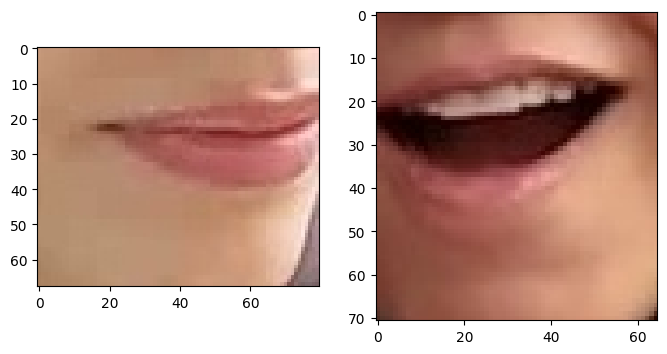

In [3]:
img1 = cv2.imread('assets/images/train/no-yawn/2760.jpg')
img1 = cv2.cvtColor(img1 , cv2.COLOR_BGR2RGB)

img2 = cv2.imread('assets/images/train/yawn/1.jpg')
img2 = cv2.cvtColor(img2 , cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)

In [4]:
width = 128
num_classes = 2
trainpath = 'assets/images/train/'
testpath = 'assets/images/test/'
trainImg = [trainpath+f for f in listdir(trainpath)]
testImg = [testpath+f for f in listdir(testpath)]
img_size = 128
batch_size = 16

In [5]:
# class GrayImageDataGenerator(Sequence):
#     def __init__(self, generator):
#         self.generator = generator

#     def __len__(self):
#         return len(self.generator)

#     def __getitem__(self, i):
#         x_batch, y_batch = self.generator[i]
#         x_batch_gray = np.expand_dims(np.mean(x_batch, axis=-1), axis=-1)
#         return x_batch_gray, y_batch
    

#     def plotImageFromDataset(self):
#         # ดึง batch แรกจาก self
#         x_batch, y_batch = next(iter(self))

#         # ดูข้อมูล
#         print("Batch shape:", x_batch.shape)
#         print("Labels:", y_batch[:10])

#         # แสดงภาพ 9 รูปแรก
#         plt.figure(figsize=(8, 8))
#         for i in range(9):
#             plt.subplot(3, 3, i + 1)
#             img = x_batch[i].squeeze()  # เอา channel ออก (เพราะ grayscale)
#             plt.imshow(img, cmap='gray')
#             plt.title(f"Label: {int(y_batch[i])}")
#             plt.axis('off')
#         plt.tight_layout()
#         plt.show()\
    
def color2gray(data):
    for x_batch, y_batch in data:
        # 1. หาค่าเฉลี่ยของทุก Channel สี (รวม RGB เข้าด้วยกัน)
        x_batch_mean = np.mean(x_batch, axis=-1)
        
        # 2. เพิ่มมิติ Channel กลับเข้าไป
        x_batch_gray = np.expand_dims(x_batch_mean, axis=-1)
        
        # ส่ง Batch ขาวดำออกไป
        yield x_batch_gray, y_batch
    
def plotImageFromDataset(self):
    # ดึง batch แรกจาก self
    x_batch, y_batch = next(iter(self))

        # ดูข้อมูล
    print("Batch shape:", x_batch.shape)
    print("Labels:", y_batch[:10])

        # แสดงภาพ 9 รูปแรก
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        img = x_batch[i].squeeze()  # เอา channel ออก (เพราะ grayscale)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {int(y_batch[i])}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    

def img2data(path):
    rawImgs = []
    labels = []
    i=0
    for imagePath in (path):
        for item in tqdm(listdir(imagePath)):
            
            if i == 8000 and  (np.where(imagePath == trainpath) or np.where(imagePath == testpath)):
                return rawImgs, labels
                        
            file = join(imagePath, item)
            if file[-1] =='g':
                img = cv2.imread(file , cv2.COLOR_BGR2RGB)
                img = cv2.resize(img ,(width,width))
                rawImgs.append(img)
                
                l = imagePath.split('/')[-1]
                if l == 'no-yawn':
                    labels.append([1,0])         
                elif l == 'yawn':
                    labels.append([0,1])
                i+=1    
            
    return rawImgs, labels


def rgb2gray(images):
    grayImgs = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        grayImgs.append(gray)
    print(grayImgs[0].shape)
    
    return grayImgs

In [6]:
x_train, y_train = img2data(trainImg)
x_test, y_test = img2data(testImg)

x_train = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_RGB2GRAY), (img_size, img_size)) for image in x_train])
y_train = np.array(y_train)
x_test = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_RGB2GRAY), (img_size, img_size)) for image in x_test])
y_test = np.array(y_test)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

100%|██████████| 758/758 [00:00<00:00, 7217.98it/s]


((5119, 128, 128), (5119, 2), (1080, 128, 128), (1080, 2))

In [ ]:
imagePath = 'assets/images/train/'
testPath = 'assets/images/test/'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_gen = train_datagen.flow(
    np.array(x_train),
    y_train,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)

val_gen = train_datagen.flow(
    np.array(x_test),
    y_test,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)

train_gen_gray = color2gray(train_gen)
val_gen_gray = color2gray(val_gen)

# train_ds = tf.keras.utils.image_dataset_from_directory(
#     imagePath,
#     labels='inferred',
#     label_mode='categorical',
#     image_size=(img_size, img_size),
#     batch_size=batch_size,
#     validation_split=0.2,
#     subset='training',
#     seed=123
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     testPath,
#     labels='inferred',
#     label_mode='categorical',
#     image_size=(img_size, img_size),
#     batch_size=batch_size,
#     validation_split=0.2,
#     subset='validation',
#     seed=123
# )

# plotImageFromDataset(train_ds,train_ds.class_names)

# train_generator_gray = GrayImageDataGenerator(train_generator)

# train_generator_gray.plotImageFormDatagen()

Found 5119 images belonging to 2 classes.
Found 1080 images belonging to 2 classes.


In [8]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(img_size,img_size,1)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763032083.548264   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763032083.548329   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763032083.548343   67313 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763032083.670924   67313 cuda_executor.cc:1001] 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 256)  │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,978 (2.18 MB)

 Trainable params: 570,978 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_gen,                # Pass training labels as 'y'
    batch_size=8,
    steps_per_epoch=8208,
    epochs=50,
    validation_data=(val_gen), # validation_data remains a tuple (X_val, Y_val)
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
)

# history = model.fit(
#     x = x_train,
#     y = y_train, # Pass training labels as 'y'
#     batch_size=8,
#     steps_per_epoch=8208,
#     epochs=50,
#     validation_data=(x_test, y_test), # validation_data remains a tuple (X_val, Y_val)
#     callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
# )

ValueError: Unrecognized data type: x=<tf_keras.src.preprocessing.image.DirectoryIterator object at 0x73a06b68d0d0> (of type <class 'tf_keras.src.preprocessing.image.DirectoryIterator'>)

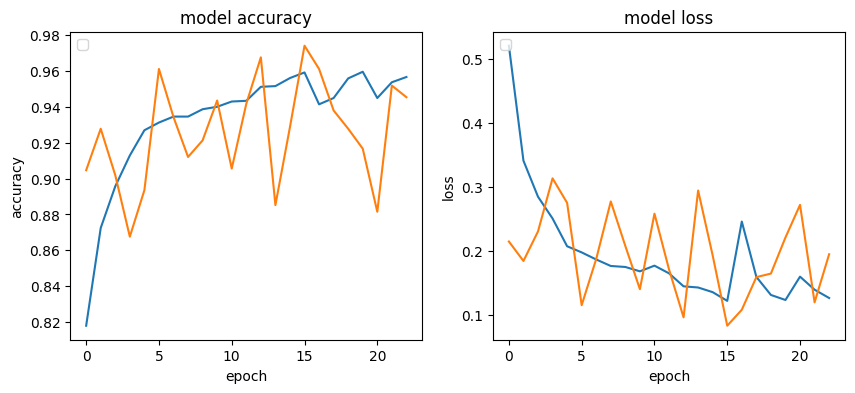

In [ ]:
model.save('yawn_model.keras')

plt.figure(figsize=(10,4))
plt.subplot(121),
plt.title('model accuracy');plt.ylabel('accuracy');plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy'])

plt.subplot(122)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['loss']);plt.plot(history.history['val_loss'])